# SLIIT IT3051 - EV Battery PHM Dual-Task System
## Week 2 - Task 2: Tree-Based Classifiers & Class Imbalance Mitigation (Critical Failure Risk)
### **Assigned Member: Person C**

---
### Overview & Objectives:
Address the 13.45:1 class imbalance using cost-sensitive learning (class_weight="balanced" and scale_pos_weight), Random Forest, and XGBoost.


### 0. Environment Setup & Data Partition Loading
Execute this cell to load the verified preprocessed matrices.


In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)

def load_data():
    dataset_path = 'ev battery_failure  Dataset.csv'
    for p in [dataset_path, f'../{dataset_path}', f'../../{dataset_path}']:
        if os.path.exists(p):
            dataset_path = p
            break
            
    df = pd.read_csv(dataset_path)
    
    # 7 Domain Features
    df['temperature_spread'] = df['cell_temperature_max'] - df['cell_temperature_avg']
    df['efficiency_gap'] = (df['charge_efficiency'] - df['discharge_efficiency']).abs()
    df['health_loss_interaction'] = (df['battery_health_percent'] * df['capacity_loss_percent']) / 100.0
    df['resistance_per_1000_cycles'] = (df['internal_resistance'] / (df['cycle_count'] + 1.0)) * 1000.0
    df['c_rate_proxy'] = df['average_charge_power_kw'] / (df['battery_capacity_kwh'] + 1e-5)
    df['cell_voltage_spread'] = df['cell_voltage_std'] / (df['cell_voltage_avg'] + 1e-5)
    df['stress_index'] = df['aggressive_acceleration_score'] * df['hard_braking_score']
    
    id_cols = ['vehicle_id', 'battery_serial']
    target_rul = 'predicted_remaining_life_cycles'
    target_fail = 'battery_failure'
    
    excluded = id_cols + [target_rul, target_fail]
    features = [c for c in df.columns if c not in excluded]
    
    num_cols = df[features].select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df[features].select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    
    # Task 1 Splits (RUL)
    df_t1 = df[df[target_rul].notnull()].copy()
    X1_tr, X1_te, y1_train, y1_test = train_test_split(df_t1[features], df_t1[target_rul], test_size=0.20, random_state=42)
    ct1 = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)], verbose_feature_names_out=False)
    X1_train = ct1.fit_transform(X1_tr)
    X1_test = ct1.transform(X1_te)
    
    # Task 2 Splits (Failure)
    X2_tr, X2_te, y2_train, y2_test = train_test_split(df[features], df[target_fail], test_size=0.20, random_state=42, stratify=df[target_fail])
    ct2 = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)], verbose_feature_names_out=False)
    X2_train = ct2.fit_transform(X2_tr)
    X2_test = ct2.transform(X2_te)
    
    feature_names = ct1.get_feature_names_out()
    return (X1_train, X1_test, y1_train, y1_test), (X2_train, X2_test, y2_train, y2_test), feature_names

print("Data Loader initialized successfully!")



Data Loader initialized successfully!


In [21]:
_, (X2_train, X2_test, y2_train, y2_test), feature_names = load_data()
print(f'Task 2 Train Shape: {X2_train.shape} | Test Shape: {X2_test.shape}')


Task 2 Train Shape: (16000, 156) | Test Shape: (4000, 156)


### Task 1: Tree Classification Baseline: The Class Imbalance Problem
Train an unweighted Decision Tree and unweighted Random Forest Classifier. Evaluate Precision, Recall, and Confusion Matrix to show how accuracy masks missed failures.


In [22]:
# TODO: Import DecisionTreeClassifier, RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# TODO: Train unweighted DecisionTree and RandomForest

dt_model = DecisionTreeClassifier(random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train both models
dt_model.fit(X2_train, y2_train)
rf_model.fit(X2_train, y2_train)

# TODO: Display confusion matrices and note the False Negatives

for name, model in [
    ("Decision Tree", dt_model),
    ("Random Forest", rf_model)
]:
    y_pred = model.predict(X2_test)

    print(f"\n{name}")

    print(classification_report(
        y2_test,
        y_pred,
        zero_division=0
    ))

    cm = confusion_matrix(y2_test, y_pred, labels=[0, 1])

    print("Confusion Matrix:")
    print(cm)

    print(f"False Negatives: {cm[1, 0]}")


Decision Tree
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3723
           1       0.54      0.54      0.54       277

    accuracy                           0.94      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.94      0.94      0.94      4000

Confusion Matrix:
[[3597  126]
 [ 127  150]]
False Negatives: 127

Random Forest
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      3723
           1       0.79      0.34      0.47       277

    accuracy                           0.95      4000
   macro avg       0.87      0.67      0.72      4000
weighted avg       0.94      0.95      0.94      4000

Confusion Matrix:
[[3698   25]
 [ 183   94]]
False Negatives: 183


### Baseline Model Reflection

The baseline Decision Tree achieved 94% accuracy, 54% failure recall and 54% failure F1-score, with 127 false negatives. The unweighted Random Forest achieved 95% accuracy and 79% failure precision, but its failure recall was only 34%, resulting in 183 false negatives.

Although Random Forest achieved higher overall accuracy, it missed more actual battery failures. This demonstrates why accuracy alone is insufficient for an imbalanced dataset. Failure recall, F1-score and false negatives are important evaluation metrics for this classification task.

**Analysis & Viva Preparation Notes**

**1. What is the Accuracy vs Recall for the unweighted Random Forest?**

The unweighted Random Forest achieved **95% overall accuracy**, but its recall for the battery failure class was only **34%**. This means the model classified most records correctly overall but detected only 34% of the actual battery failures. The high accuracy is partly due to the dataset containing significantly more normal batteries than failed batteries.

**2. How many actual battery failures were missed (False Negatives) by the unweighted model?**

The unweighted Random Forest missed **183 actual battery failures** out of 277 failed batteries in the test set. These are false negatives, where the model incorrectly predicted a failed battery as normal.

### Task 2: Cost-Sensitive Tree Learning (class_weight='balanced')
Train RandomForestClassifier with class_weight='balanced'. Evaluate the trade-off in Precision vs Recall.


In [23]:
# TODO: Train a class-weighted Random Forest

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the balanced model
rf_balanced.fit(X2_train, y2_train)

# Predict on the test set
y_pred_balanced = rf_balanced.predict(X2_test)

# Evaluate performance
print("Class-Weighted Random Forest")

print(classification_report(
    y2_test,
    y_pred_balanced,
    zero_division=0
))

cm_balanced = confusion_matrix(
    y2_test,
    y_pred_balanced,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm_balanced)

print(f"False Negatives: {cm_balanced[1, 0]}")

Class-Weighted Random Forest
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      3723
           1       0.63      0.51      0.56       277

    accuracy                           0.94      4000
   macro avg       0.79      0.74      0.77      4000
weighted avg       0.94      0.94      0.94      4000

Confusion Matrix:
[[3638   85]
 [ 135  142]]
False Negatives: 135


The class-weighted Random Forest improved failure recall from 34% to 51% and reduced false negatives from 183 to 135 compared with the baseline Random Forest. The failure F1-score increased from 47% to 56%. However, failure precision decreased from 79% to 63%, indicating a trade-off between detecting more failures and producing more false positives.

**Analysis & Viva Preparation Notes**

**1. By how much did Recall increase when using `class_weight='balanced'`?**

Failure recall increased from **34% to 51%**, an improvement of **17 percentage points**. The number of false negatives decreased from 183 to 135, meaning the balanced Random Forest correctly identified 48 additional battery failures.

**2. What happened to Precision, and why is this an acceptable operational trade-off in battery safety?**

Failure precision decreased from **79% to 63%** because the balanced model predicted more batteries as failures, increasing false positives from 25 to 85.

This can be an acceptable operational trade-off in battery safety because missing a genuinely failing battery may have more serious consequences than unnecessarily inspecting a healthy battery. However, the increased false alarms may lead to additional inspection costs and maintenance work. The appropriate balance depends on the actual consequences of each type of error.

### Task 3: Extreme Gradient Boosting with scale_pos_weight
Train HistGradientBoostingClassifier or XGBClassifier with scale_pos_weight = 13.45 (ratio of normal to failure instances).


In [24]:
# TODO: Import XGBClassifier and evaluation metrics

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

# TODO: Calculate scale_pos_weight from the training class distribution

negative_count = (y2_train == 0).sum()
positive_count = (y2_train == 1).sum()

scale_weight = negative_count / positive_count

print(f"Scale Pos Weight: {scale_weight:.2f}")


# TODO: Train a cost-sensitive XGBoost classifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X2_train, y2_train)


# TODO: Generate class predictions and failure probabilities

y_pred_xgb = xgb_model.predict(X2_test)
y_prob_xgb = xgb_model.predict_proba(X2_test)[:, 1]


# TODO: Display classification report and confusion matrix

print("\nCost-Sensitive XGBoost")

print(classification_report(
    y2_test,
    y_pred_xgb,
    zero_division=0
))

cm_xgb = confusion_matrix(
    y2_test,
    y_pred_xgb,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm_xgb)

print(f"False Negatives: {cm_xgb[1, 0]}")


# TODO: Evaluate PR-AUC and ROC-AUC

pr_auc_xgb = average_precision_score(
    y2_test,
    y_prob_xgb
)

roc_auc_xgb = roc_auc_score(
    y2_test,
    y_prob_xgb
)

print(f"PR-AUC (Average Precision): {pr_auc_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")

Scale Pos Weight: 13.45

Cost-Sensitive XGBoost
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      3723
           1       0.45      0.91      0.60       277

    accuracy                           0.92      4000
   macro avg       0.72      0.91      0.78      4000
weighted avg       0.96      0.92      0.93      4000

Confusion Matrix:
[[3409  314]
 [  24  253]]
False Negatives: 24
PR-AUC (Average Precision): 0.7420
ROC-AUC: 0.9756


The cost-sensitive XGBoost model was trained using a scale_pos_weight of 13.45 to address the class imbalance. It achieved 91% failure recall, 45% failure precision and a 60% failure F1-score. The model reduced false negatives to 24, although false positives increased to 314. It also achieved a PR-AUC (Average Precision) of 0.7420 and a ROC-AUC of 0.9756. These results demonstrate a substantial improvement in failure detection, with a trade-off in precision.

**Analysis & Viva Preparation Notes**

**1. How does cost-sensitive boosting perform compared to balanced Random Forest?**

The original cost-sensitive XGBoost achieved **91% failure recall**, compared to **51%** for the balanced Random Forest, an improvement of 40 percentage points. It also achieved a higher failure F1-score (60% versus 56%) and PR-AUC (0.7420 versus 0.6015).

XGBoost reduced false negatives from 135 to just 24, meaning it detected significantly more actual battery failures. However, its failure precision was lower (45% versus 63%), and false positives increased from 85 to 314.

This demonstrates that cost-sensitive boosting substantially improved failure detection at the evaluated threshold, but at the cost of more false alarms.

**2. What are the top failure-driving features identified by the boosting model?**

According to the original XGBoost model's feature importance scores, the five most important features were:

1. **Battery health percentage** (`battery_health_percent`): 0.1576
2. **Thermal runaway risk** (`thermal_runaway_risk`): 0.1351
3. **Capacity loss percentage** (`capacity_loss_percent`): 0.0722
4. **State of health** (`state_of_health`): 0.0589
5. **Thermal health score** (`thermal_health_score`): 0.0450

These features indicate that battery health, capacity degradation and thermal conditions are important predictors in the trained model.

However, feature importance measures a feature's contribution to the model's predictions; it does not establish that the feature directly causes battery failure.

In [25]:
# TODO: Import hyperparameter tuning tools

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

# TODO: Calculate class imbalance weight

negative_count = (y2_train == 0).sum()
positive_count = (y2_train == 1).sum()

scale_weight = negative_count / positive_count

# TODO: Define the hyperparameter search space

param_distributions = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "scale_pos_weight": [scale_weight / 2, scale_weight]
}

# TODO: Initialize XGBoost

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=2
)

# TODO: Configure stratified cross-validation

cv = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

# TODO: Configure RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=2,
    refit=True
)

# TODO: Run hyperparameter tuning

random_search.fit(X2_train, y2_train)

# TODO: Display the best results

print("\nBest Hyperparameters:")
print(random_search.best_params_)

print(
    f"\nBest CV PR-AUC: "
    f"{random_search.best_score_:.4f}"
)

# TODO: Retrieve the tuned model

xgb_tuned = random_search.best_estimator_

Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, n_estimators=100, scale_pos_weight=6.726738934056007, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=4, n_estimators=100, scale_pos_weight=6.726738934056007, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, scale_pos_weight=6.726738934056007, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, scale_pos_weight=6.726738934056007, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=100, scale_pos_weight=6.726738934056007, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=100, scale_pos_weight=6.726738934056007, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=1.0, lea

In [26]:
# TODO: Generate predictions using the tuned model

y_pred_tuned = xgb_tuned.predict(X2_test)
y_prob_tuned = xgb_tuned.predict_proba(X2_test)[:, 1]


# TODO: Display classification report

print("Tuned XGBoost Classification Report:")

print(classification_report(
    y2_test,
    y_pred_tuned,
    zero_division=0
))


# TODO: Display confusion matrix and false negatives

cm_tuned = confusion_matrix(
    y2_test,
    y_pred_tuned,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm_tuned)

print(f"False Negatives: {cm_tuned[1, 0]}")


# TODO: Calculate PR-AUC and ROC-AUC

pr_auc_tuned = average_precision_score(
    y2_test,
    y_prob_tuned
)

roc_auc_tuned = roc_auc_score(
    y2_test,
    y_prob_tuned
)

print(f"PR-AUC: {pr_auc_tuned:.4f}")
print(f"ROC-AUC: {roc_auc_tuned:.4f}")

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3723
           1       0.63      0.90      0.74       277

    accuracy                           0.96      4000
   macro avg       0.81      0.93      0.86      4000
weighted avg       0.97      0.96      0.96      4000

Confusion Matrix:
[[3575  148]
 [  29  248]]
False Negatives: 29
PR-AUC: 0.7798
ROC-AUC: 0.9811


### XGBoost Hyperparameter Tuning Analysis

RandomizedSearchCV was implemented with two-fold StratifiedKFold cross-validation and eight randomly selected hyperparameter combinations. Average Precision was used as the optimization metric to account for the imbalanced failure classes.

The selected configuration used 200 estimators, a maximum depth of 3, a learning rate of 0.1 and a scale_pos_weight of approximately 6.73. It achieved a cross-validation PR-AUC of 0.7816.

On the test set, the tuned XGBoost achieved 96% accuracy, 63% failure precision, 90% failure recall, a 74% failure F1-score, a PR-AUC of 0.7798 and a ROC-AUC of 0.9811.

Compared with the original XGBoost, false positives decreased from 314 to 148, while false negatives increased slightly from 24 to 29. Overall, tuning improved precision and F1-score while maintaining high failure recall.

### Task 4: Precision-Recall & ROC Curve Comparison
Plot side-by-side ROC Curves and Precision-Recall Curves comparing all evaluated classification models.


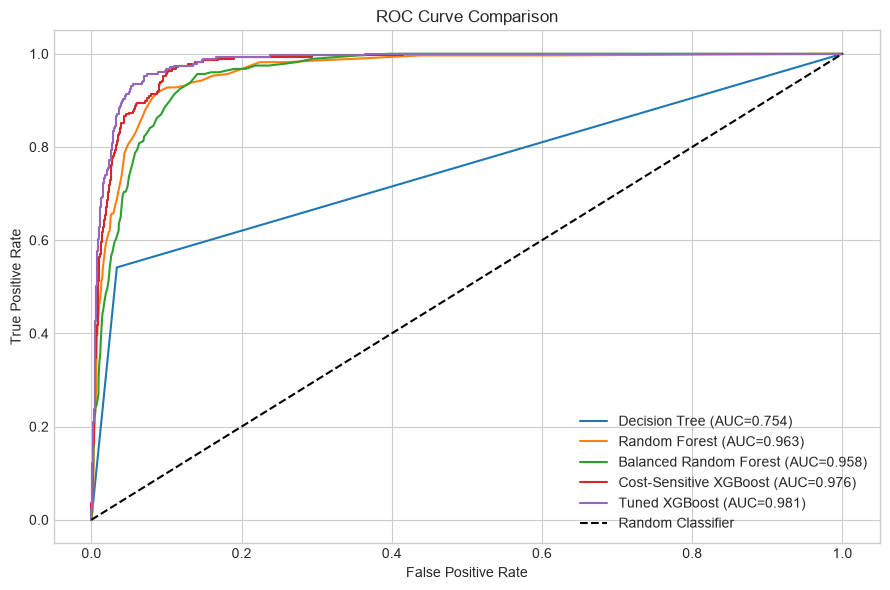

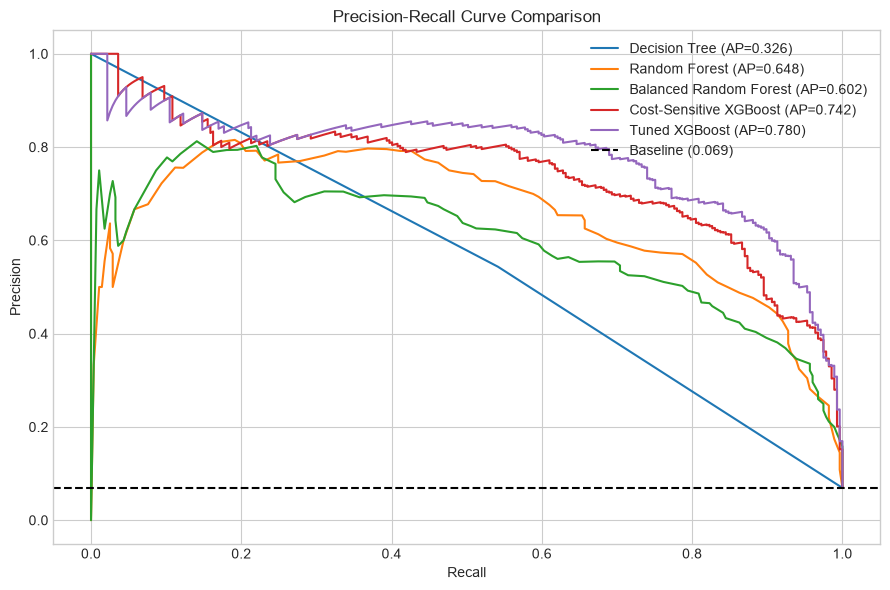


Model Performance Comparison:
                 Model  ROC-AUC   PR-AUC
         Tuned XGBoost 0.981110 0.779817
Cost-Sensitive XGBoost 0.975592 0.741981
         Random Forest 0.962814 0.648363
Balanced Random Forest 0.958270 0.601506
         Decision Tree 0.753836 0.326052


In [32]:
# TODO: Import ROC and Precision-Recall evaluation metrics

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

import matplotlib.pyplot as plt
import pandas as pd


# TODO: Collect all trained models, including tuned XGBoost

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Balanced Random Forest": rf_balanced,
    "Cost-Sensitive XGBoost": xgb_model,
    "Tuned XGBoost": xgb_tuned
}


# TODO: Calculate ROC-AUC and PR-AUC for each model

results = []

plt.figure(figsize=(9, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X2_test)[:, 1]

    roc_auc = roc_auc_score(y2_test, y_prob)
    pr_auc = average_precision_score(y2_test, y_prob)

    results.append({
        "Model": name,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    fpr, tpr, _ = roc_curve(y2_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )


# TODO: Plot ROC curves

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# TODO: Plot Precision-Recall curves

plt.figure(figsize=(9, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X2_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y2_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y2_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={pr_auc:.3f})"
    )


# TODO: Plot baseline precision using failure prevalence

baseline = (y2_test == 1).mean()

plt.axhline(
    y=baseline,
    color="black",
    linestyle="--",
    label=f"Baseline ({baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# TODO: Display model comparison table

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

print("\nModel Performance Comparison:")
print(results_df.to_string(index=False))

### ROC and Precision-Recall Curve Analysis

The four tree-based classification models were evaluated using ROC-AUC and PR-AUC (Average Precision).

Cost-Sensitive XGBoost achieved the highest ROC-AUC (0.9756) and PR-AUC (0.7420), indicating strong discrimination between normal and failed batteries across different classification thresholds.

The baseline Random Forest achieved a PR-AUC of 0.6484, while the class-weighted Random Forest achieved 0.6015. Although class weighting improved failure recall at the default classification threshold, it did not improve overall PR-AUC.

The Decision Tree achieved the lowest PR-AUC (0.3261).

XGBoost also achieved 91% failure recall and reduced false negatives to 24. However, its precision was 45%, highlighting the trade-off between detecting more failures and generating false alarms.

**Analysis & Viva Preparation Notes**

**1. Why is the PR-AUC curve visually more informative than the ROC curve for a 13.45:1 imbalanced dataset?**

The dataset contains approximately 13.45 normal batteries for every failed battery. In this situation, the ROC curve can appear strong even when a model generates a considerable number of false positives, because the false-positive rate is calculated against the large number of normal batteries.

The Precision-Recall (PR) curve focuses on the minority failure class by showing the relationship between precision and recall. It makes the trade-off between detecting actual battery failures and generating false alarms more visible.

Therefore, PR-AUC is particularly informative for comparing the models on this imbalanced dataset.

**2. Which model achieved the highest PR-AUC score?**

The **tuned XGBoost achieved the highest PR-AUC of 0.7798** among the five evaluated model configurations.

The PR-AUC scores were:

| Model | PR-AUC |
|---|---:|
| Baseline Decision Tree | 0.3261 |
| Baseline Random Forest | 0.6484 |
| Balanced Random Forest | 0.6015 |
| Original cost-sensitive XGBoost | 0.7420 |
| Tuned XGBoost | **0.7798** |

The tuned XGBoost also achieved 90% failure recall and a 74% failure F1-score. These results demonstrate improved performance in identifying battery failures while balancing precision and recall.

Top 15 Important Features:
                Feature  Importance
 battery_health_percent    0.157589
   thermal_runaway_risk    0.135127
  capacity_loss_percent    0.072157
        state_of_health    0.058909
   thermal_health_score    0.045048
        previous_faults    0.036581
    internal_resistance    0.033134
            aging_score    0.030327
   battery_stress_index    0.030251
      BMS_warning_count    0.030173
abnormal_voltage_events    0.025501
      vehicle_age_years    0.022739
       cell_voltage_avg    0.018593
      charge_efficiency    0.018563
health_loss_interaction    0.018402


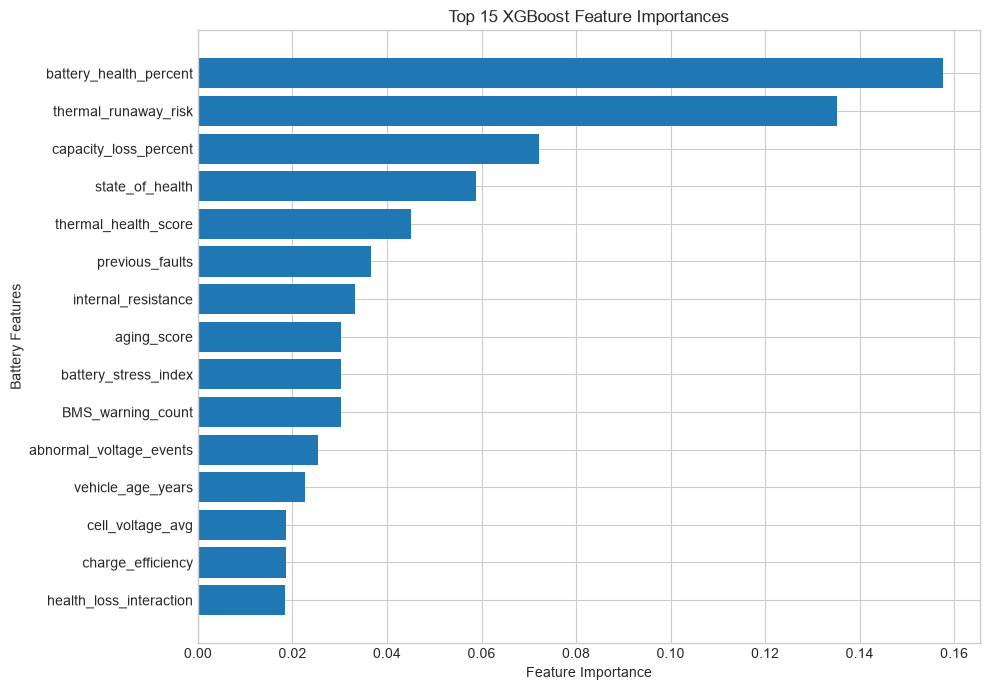

In [31]:
# TODO: Extract XGBoost feature importance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance scores
importance = xgb_model.feature_importances_

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Select the top 15 features
top_features = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .head(15)
)

# Display results
print("Top 15 Important Features:")
print(top_features.to_string(index=False))

# TODO: Plot feature importance

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Battery Features")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

### Final Model Selection and Justification

Five model configurations were evaluated for battery failure prediction: Decision Tree, Random Forest, Balanced Random Forest, Cost-Sensitive XGBoost and Tuned XGBoost.

The dataset has a class imbalance ratio of approximately 13.45:1. Therefore, model evaluation focused on failure-class precision, recall, F1-score, PR-AUC and false negatives rather than accuracy alone.

**Tuned XGBoost was selected as the final model for this experiment** because it achieved the highest observed PR-AUC (0.7798), ROC-AUC (0.9811) and failure-class F1-score (0.74) among the evaluated configurations.

The tuned model achieved 90% failure recall and 63% failure precision. It correctly detected 248 of the 277 failed batteries in the test set, with 29 false negatives and 148 false positives.

Compared with the original Cost-Sensitive XGBoost, tuning reduced false positives from 314 to 148 and improved failure precision from 45% to 63%. However, failure recall decreased slightly from 91% to 90%, and false negatives increased from 24 to 29.

The selected model provides a more balanced precision-recall trade-off at the evaluated classification threshold. Nevertheless, the original Cost-Sensitive XGBoost remains relevant when minimizing missed failures is the primary operational requirement.

The tuning experiment used RandomizedSearchCV with eight parameter combinations, two-fold stratified cross-validation and Average Precision as the optimization metric. The selected configuration achieved a cross-validation PR-AUC of 0.7816.

**Limitations:** The model requires further validation on independent battery data before real-world deployment. The current results were obtained using a single train-test split, and the test set was inspected during model development. The potential effects of data leakage, correlated features and different classification thresholds should also be investigated.